# 5-0. 전국 수요 예측 — 관계 탐색·시계열 분석 (G-9)

> PROJECT.md §5.0.5 / G-9 게이트. **모델 착수 전 필수.** 명제가 아니라 "데이터에
> 예측 가능한 구조가 실제로 있는가 + 무엇을 입력으로 줄 수 있는가"를 본다.
>
> 타깃 `real_demand_land`(전국 계통수요, MW). 베이스라인 = `land_est_demand_da`(KPX 하루전).
> 제주 2단계(`jeju_demand_forecaster`)의 전국판. 학습창 train 2020–2024 / val 2025 / test 2026.
>
> **점검 항목**: ①결측·품질 ②시계열 구조(주기·추세·안정성) ③기온↔수요 관계
> ④5지점 기상·공간평균 타당성 ⑤예보 vs 실측 기상 정합(서빙 가능 피처) ⑥train↔test 분포 겹침
> ⑦자기상관(lag 구조) ⑧베이스라인 오차. 산출: 그림 + 표 + REPORT.

In [1]:
import os, sqlite3, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
warnings.filterwarnings('ignore')
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110

HERE = os.getcwd()
FIG = os.path.join(HERE, 'fig'); os.makedirs(FIG, exist_ok=True)
TAB = os.path.join(HERE, 'tab'); os.makedirs(TAB, exist_ok=True)
DB = os.path.normpath(os.path.join(HERE, '..', '..',
        '1. data_fetcher_and_db', 'data', 'input_data_land.db'))

STATIONS = ['daegwallyeong', 'wonju', 'seosan', 'pohang', 'yeonggwang']
# historical 기상(지점별), 모델 후보 5종
WX = ['temp_c', 'humidity', 'solar_rad', 'wind_spd', 'total_cloud', 'midlow_cloud']
pull = ['timestamp', 'real_demand_land', 'land_est_demand_da', 'day_type']
for st in STATIONS:
    for w in WX:
        pull.append(f'{w}_{st}')

con = sqlite3.connect(DB)
df = pd.read_sql(f"SELECT {', '.join(pull)} FROM historical", con, parse_dates=['timestamp'])
con.close()
df = df.sort_values('timestamp').reset_index(drop=True)
# 5지점 공간평균 (전국 단일 물리량 가정)
for w in WX:
    df[w] = df[[f'{w}_{st}' for st in STATIONS]].mean(axis=1)
df['year'] = df.timestamp.dt.year
df['month'] = df.timestamp.dt.month
df['hour'] = df.timestamp.dt.hour
df['dow'] = df.timestamp.dt.dayofweek
df['date'] = df.timestamp.dt.normalize()
print(df.shape, df.timestamp.min(), '~', df.timestamp.max())
df[['timestamp','real_demand_land','land_est_demand_da','temp_c','day_type']].head()

(56352, 45) 2020-01-01 00:00:00 ~ 2026-06-05 23:00:00


,timestamp,real_demand_land,land_est_demand_da,temp_c,day_type
0,2020-01-01 00:00:00,65340.5,62390.0,-6.96,holiday
1,2020-01-01 01:00:00,62578.0,60010.0,-6.36,holiday
2,2020-01-01 02:00:00,60505.4,57730.0,-6.06,holiday
3,2020-01-01 03:00:00,58633.3,56440.0,-5.80,holiday
4,2020-01-01 04:00:00,58234.0,55940.0,-5.54,holiday


## 1. 데이터 품질 — 결측·이상치·베이스라인 오차

타깃 결측(시간보간 대상)·0값 점검, 그리고 우리가 이겨야 할 KPX 하루전 베이스라인 MAPE.

In [2]:
y = df['real_demand_land']
print('real_demand_land : NaN=%d  zero=%d  min=%.0f  max=%.0f  mean=%.0f'
      % (y.isna().sum(), (y==0).sum(), y.min(), y.max(), y.mean()))
print('land_est_demand_da: NaN=%d' % df.land_est_demand_da.isna().sum())

# 타깃 0/결측 → 시간보간 (dropna 금지 규칙)
d = df.copy()
d.loc[d.real_demand_land==0,'real_demand_land'] = np.nan
d['real_demand_land'] = d.set_index('timestamp')['real_demand_land'].interpolate(method='time').values

def mape(a,b):
    m=(a>0)&(~np.isnan(a))&(~np.isnan(b)); return float(np.mean(np.abs(a[m]-b[m])/a[m])*100)
rows=[]
for yr,g in d.groupby('year'):
    rows.append(dict(year=yr, n=len(g), dem_nan=int(df[df.year==yr].real_demand_land.isna().sum()),
                     dem_mean=g.real_demand_land.mean(),
                     base_mape=mape(g.real_demand_land.values, g.land_est_demand_da.values)))
summary = pd.DataFrame(rows)
summary.to_csv(os.path.join(TAB,'5-0_year_summary.csv'), index=False)
print(summary.to_string(index=False))

real_demand_land : NaN=300  zero=0  min=33372  max=96832  mean=64036
land_est_demand_da: NaN=48
 year    n  dem_nan     dem_mean  base_mape
 2020 8784        8 61568.135354   6.002036
 2021 8760        3 64218.378796   5.793154
 2022 8760       40 65802.947671   5.812205
 2023 8760       34 64655.569424   4.997615
 2024 8784       16 64465.910531   5.076168
 2025 8760       51 64427.980590   5.479038
 2026 3744      148 61739.822489   5.483835


## 2. 시계열 구조 — 주기성 (시간 / 요일 / 월)

전력수요의 핵심 신호. 일중(난방·냉방·업무), 주간(평일·주말), 계절(여름·겨울 쌍봉) 패턴.

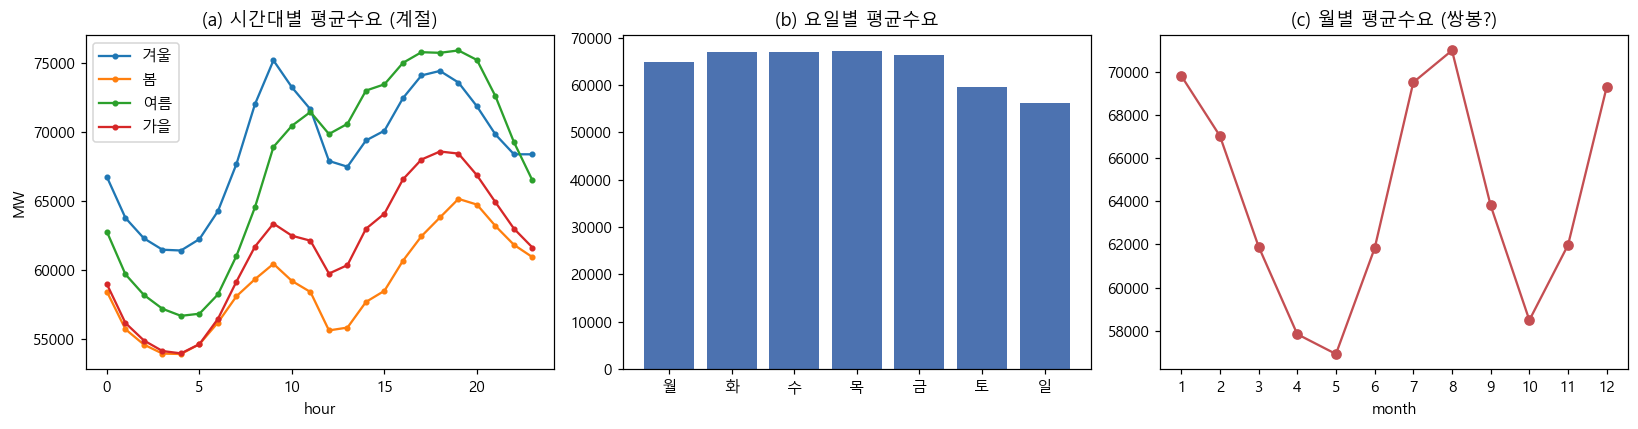

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))
# (a) 계절별 시간 프로파일
d['season'] = d.month.map({12:'겨울',1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',
                           6:'여름',7:'여름',8:'여름',9:'가을',10:'가을',11:'가을'})
for s in ['겨울','봄','여름','가을']:
    p = d[d.season==s].groupby('hour').real_demand_land.mean()
    ax[0].plot(p.index, p.values, marker='o', ms=3, label=s)
ax[0].set_title('(a) 시간대별 평균수요 (계절)'); ax[0].set_xlabel('hour'); ax[0].set_ylabel('MW'); ax[0].legend()
# (b) 요일
dd = ['월','화','수','목','금','토','일']
p = d.groupby('dow').real_demand_land.mean()
ax[1].bar([dd[i] for i in p.index], p.values, color='#4C72B0'); ax[1].set_title('(b) 요일별 평균수요')
# (c) 월
p = d.groupby('month').real_demand_land.mean()
ax[2].plot(p.index, p.values, marker='o', color='#C44E52'); ax[2].set_title('(c) 월별 평균수요 (쌍봉?)')
ax[2].set_xlabel('month'); ax[2].set_xticks(range(1,13))
plt.tight_layout(); plt.savefig(os.path.join(FIG,'5-0_seasonality.png'), bbox_inches='tight'); plt.show()

## 3. 추세 & 시간적 안정성 (연도별 레짐)

연도별 수요 레벨이 표류하는지 — 표류가 크면 lag/level 피처와 학습창 설계에 영향.

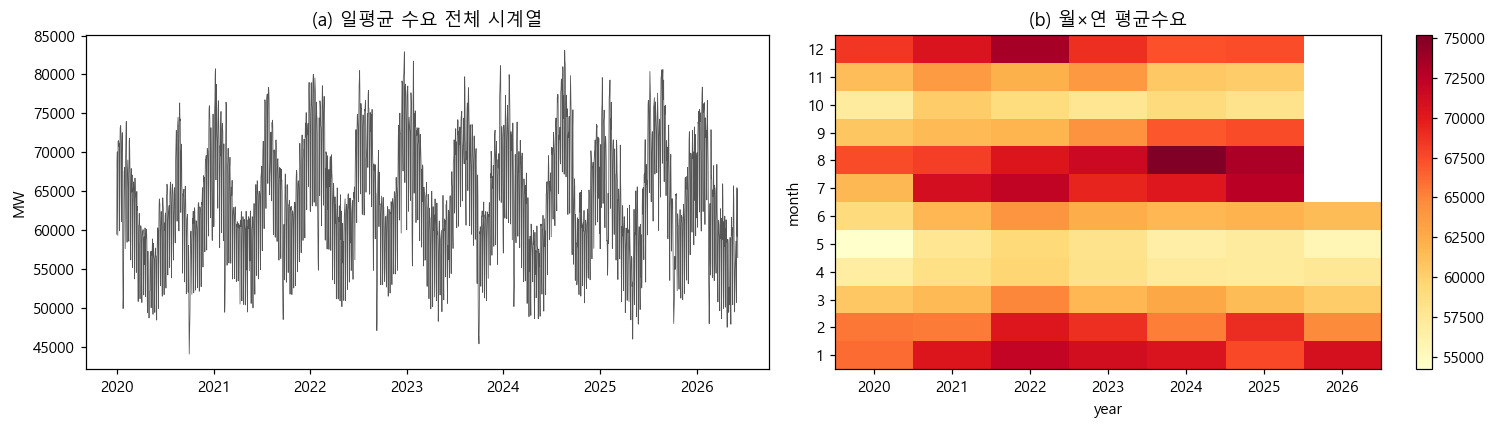

연평균 수요(MW):
year
2020    61568.0
2021    64218.0
2022    65803.0
2023    64656.0
2024    64466.0
2025    64428.0
2026    61740.0

연도별 표준편차(MW):
year
2020     8235.0
2021     8816.0
2022     9553.0
2023     9529.0
2024    10036.0
2025    10128.0
2026     9925.0


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
daily = d.groupby('date').real_demand_land.mean()
ax[0].plot(daily.index, daily.values, lw=0.5, color='#555')
ax[0].set_title('(a) 일평균 수요 전체 시계열'); ax[0].set_ylabel('MW')
# 연*월 히트맵
piv = d.pivot_table('real_demand_land','month','year','mean')
im = ax[1].imshow(piv.values, aspect='auto', cmap='YlOrRd', origin='lower')
ax[1].set_xticks(range(len(piv.columns))); ax[1].set_xticklabels(piv.columns)
ax[1].set_yticks(range(12)); ax[1].set_yticklabels(range(1,13))
ax[1].set_title('(b) 월×연 평균수요'); ax[1].set_xlabel('year'); ax[1].set_ylabel('month')
plt.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.savefig(os.path.join(FIG,'5-0_trend.png'), bbox_inches='tight'); plt.show()
print('연평균 수요(MW):'); print(d.groupby('year').real_demand_land.mean().round(0).to_string())
print('\n연도별 표준편차(MW):'); print(d.groupby('year').real_demand_land.std().round(0).to_string())

## 4. 기온 ↔ 수요 관계 (냉난방 U자)

전력수요의 최대 외생 동인. 저온(난방)·고온(냉방)에서 수요가 오르는 U(또는 V)자 기대.

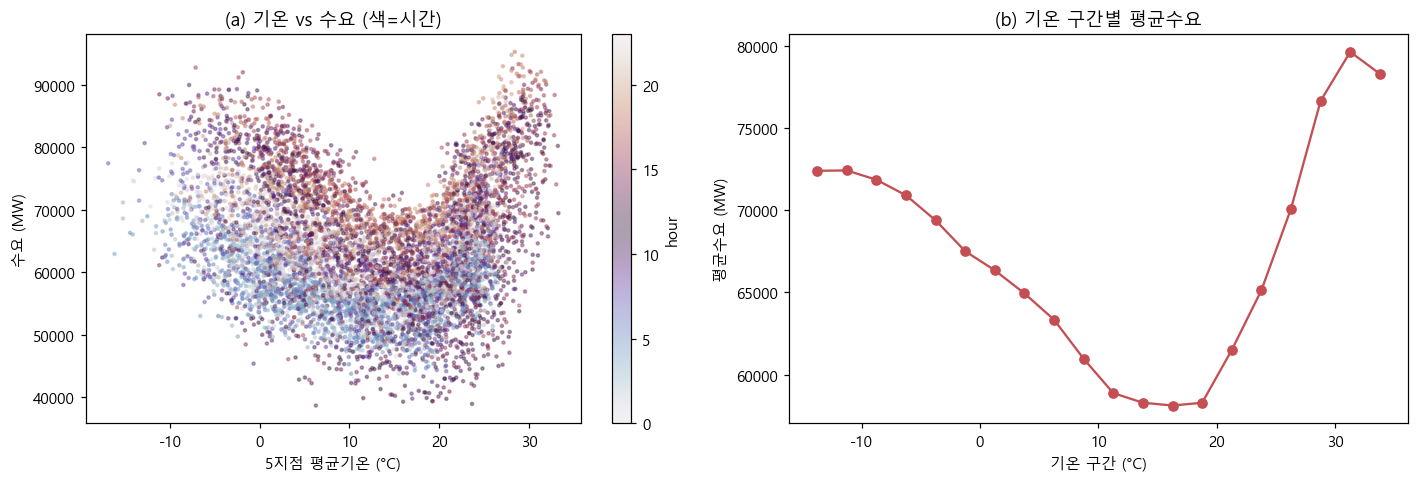

상관(피어슨):
  temp_c        -0.018
  humidity      -0.093
  solar_rad     +0.017
  wind_spd      +0.140
  total_cloud   +0.054
  midlow_cloud  +0.028


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
samp = d.sample(min(8000,len(d)), random_state=0)
sc = ax[0].scatter(samp.temp_c, samp.real_demand_land, s=4, c=samp.hour, cmap='twilight', alpha=.4)
ax[0].set_xlabel('5지점 평균기온 (°C)'); ax[0].set_ylabel('수요 (MW)')
ax[0].set_title('(a) 기온 vs 수요 (색=시간)'); plt.colorbar(sc, ax=ax[0], label='hour')
# 기온 구간별 평균수요
d['tbin'] = pd.cut(d.temp_c, bins=np.arange(-15,40,2.5))
p = d.groupby('tbin').real_demand_land.mean()
cx = [iv.mid for iv in p.index]
ax[1].plot(cx, p.values, marker='o', color='#C44E52')
ax[1].set_xlabel('기온 구간 (°C)'); ax[1].set_ylabel('평균수요 (MW)'); ax[1].set_title('(b) 기온 구간별 평균수요')
plt.tight_layout(); plt.savefig(os.path.join(FIG,'5-0_temp_demand.png'), bbox_inches='tight'); plt.show()
print('상관(피어슨):')
for c in ['temp_c','humidity','solar_rad','wind_spd','total_cloud','midlow_cloud']:
    print('  %-13s %+.3f' % (c, d[['real_demand_land',c]].corr().iloc[0,1]))

## 5. 5지점 기상 비교 & 공간평균 타당성

제주는 3지점 공간평균이 단일지점보다 좋았다. 전국 5지점도 평균이 타당한지(지점 간 상관·대표성) 점검.

In [6]:
# 5지점 기온 상관
tcols = [f'temp_c_{st}' for st in STATIONS]
corr = df[tcols].corr()
corr.columns = STATIONS; corr.index = STATIONS
print('5지점 기온 상관행렬:'); print(corr.round(3).to_string())
# 각 지점 기온 vs 수요 상관 (대표성)
print('\n지점별 기온↔수요 상관:')
for st in STATIONS:
    c = pd.concat([d.real_demand_land, df[f'temp_c_{st}']],axis=1).corr().iloc[0,1]
    print('  %-13s %+.3f' % (st, c))
print('\n5지점 평균 기온↔수요 상관: %+.3f' % d[['real_demand_land','temp_c']].corr().iloc[0,1])

5지점 기온 상관행렬:
               daegwallyeong  wonju  seosan  pohang  yeonggwang
daegwallyeong          1.000  0.969   0.964   0.968       0.959
wonju                  0.969  1.000   0.978   0.958       0.968
seosan                 0.964  0.978   1.000   0.952       0.983
pohang                 0.968  0.958   0.952   1.000       0.957
yeonggwang             0.959  0.968   0.983   0.957       1.000

지점별 기온↔수요 상관:
  daegwallyeong -0.026
  wonju         -0.026
  seosan        -0.011
  pohang        -0.023
  yeonggwang    -0.000

5지점 평균 기온↔수요 상관: -0.018


## 6. 예보 vs 실측 기상 정합 — 서빙 가능 피처 (★ 핵심)

모델 입력은 **forecast 테이블에도 존재하는 변수만** 써야 D+1 서빙이 된다(제주 2단계와 동일 제약).
historical 과 forecast 의 컬럼을 매핑해 **습도처럼 예보에 없는 변수**를 가려낸다.

In [7]:
con = sqlite3.connect(DB)
fc = pd.read_sql('SELECT * FROM forecast', con, parse_dates=['timestamp'])
con.close()
fc_cols = set(c.rsplit('_',1)[0] if c.split('_')[-1] in STATIONS else c for c in fc.columns)
print('forecast 테이블 기상 변수(지점 접미사 제거):')
# 매핑 표
mapping = {
 'temp_c':'temp', 'solar_rad':'radiation', 'wind_spd':'wind_spd_10m',
 'total_cloud':'total_cloud', 'midlow_cloud':'midlow_cloud',
 'humidity':'(없음)', 'rainfall':'(없음)', 'snow_depth':'(없음)',
}
rows=[]
for hcol, fcol in mapping.items():
    avail = any(fcol in c for c in fc.columns) if fcol!='(없음)' else False
    rows.append(dict(historical=hcol, forecast=fcol, 서빙가능=('O' if avail else 'X')))
mp = pd.DataFrame(rows); mp.to_csv(os.path.join(TAB,'5-0_feature_availability.csv'), index=False)
print(mp.to_string(index=False))
print('\nforecast 범위:', fc.timestamp.min(),'~',fc.timestamp.max(),' rows=',len(fc))
print('forecast day_type 존재:', 'day_type' in fc.columns, '| land_est_demand_da 존재:', 'land_est_demand_da' in fc.columns)

forecast 테이블 기상 변수(지점 접미사 제거):
  historical     forecast 서빙가능
      temp_c         temp    O
   solar_rad    radiation    O
    wind_spd wind_spd_10m    O
 total_cloud  total_cloud    O
midlow_cloud midlow_cloud    O
    humidity         (없음)    X
    rainfall         (없음)    X
  snow_depth         (없음)    X

forecast 범위: 2025-12-10 00:00:00 ~ 2026-06-06 23:00:00  rows= 4296
forecast day_type 존재: True | land_est_demand_da 존재: True


## 7. train↔test 분포 겹침 (covariate shift)

train(2020–2024) 과 test(2026, 1~6월 부분) 의 입력 분포가 겹쳐야 정직한 검증.
test 가 train 범위를 벗어나면 외삽이 된다. 기온·수요 분포로 확인.

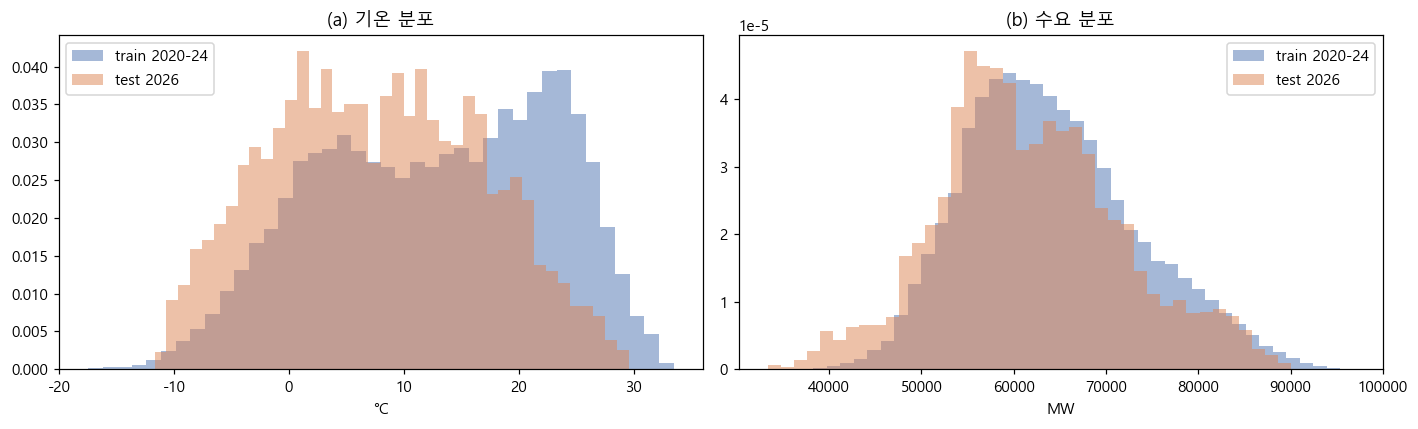

test 2026 가 train 범위(0.1~99.9%) 밖 비율:
  temp_c             0.00%
  real_demand_land   1.95%

test 기간: 2026-01-01 00:00:00 ~ 2026-06-05 23:00:00


In [8]:
tr = d[d.year<=2024]; te = d[d.year==2026]
fig, ax = plt.subplots(1,2, figsize=(13,4))
for name,g,c in [('train 2020-24',tr,'#4C72B0'),('test 2026',te,'#DD8452')]:
    ax[0].hist(g.temp_c.dropna(), bins=40, density=True, alpha=.5, label=name, color=c)
    ax[1].hist(g.real_demand_land.dropna(), bins=40, density=True, alpha=.5, label=name, color=c)
ax[0].set_title('(a) 기온 분포'); ax[0].set_xlabel('°C'); ax[0].legend()
ax[1].set_title('(b) 수요 분포'); ax[1].set_xlabel('MW'); ax[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG,'5-0_covariate_shift.png'), bbox_inches='tight'); plt.show()
# test 가 train 범위 밖인 비율
def outside(col):
    lo,hi = tr[col].quantile([.001,.999]); return float(((te[col]<lo)|(te[col]>hi)).mean()*100)
print('test 2026 가 train 범위(0.1~99.9%) 밖 비율:')
for c in ['temp_c','real_demand_land']:
    print('  %-18s %.2f%%' % (c, outside(c)))
print('\ntest 기간:', te.timestamp.min(),'~',te.timestamp.max())

## 8. 자기상관 — lag 구조

수요는 강한 일주기(lag24)·주주기(lag168) 자기상관을 가진다. lag/roll 피처 설계 근거.

In [9]:
s = d.set_index('timestamp').real_demand_land
lags = [1,2,3,6,12,24,48,168]
print('자기상관(전구간):')
for L in lags:
    print('  lag %4dh : %+.3f' % (L, s.autocorr(L)))
# 직전 24h 평균(roll) 과의 관계
roll24 = s.shift(1).rolling(24,min_periods=24).mean()
print('\nroll_mean_24h ↔ 현재수요 상관: %+.3f' % pd.concat([s,roll24],axis=1).corr().iloc[0,1])
print('lag_24h ↔ 현재수요 상관      : %+.3f' % pd.concat([s,s.shift(24)],axis=1).corr().iloc[0,1])

자기상관(전구간):
  lag    1h : +0.972
  lag    2h : +0.907
  lag    3h : +0.820
  lag    6h : +0.572
  lag   12h : +0.369
  lag   24h : +0.778
  lag   48h : +0.566
  lag  168h : +0.836

roll_mean_24h ↔ 현재수요 상관: +0.728
lag_24h ↔ 현재수요 상관      : +0.778


## 9. 요약 & 피처 후보 (모델 결정용)

아래 표를 근거로 다음 단계에서 **최종 입력 피처와 모델 구조를 사용자에게 확정**받는다(§0.6).

In [10]:
report = f'''# 5-0 EDA 요약 — 전국 수요 예측 (G-9)

## 데이터
- 타깃 real_demand_land: 2020-01 ~ 2026-06-05, 56,352행. 결측 300(시간보간), 0값 없음. 33k~97k MW.
- 베이스라인 land_est_demand_da(KPX 하루전): 연도별 MAPE 5.0~6.0% (2026 5.29%). 이걸 이기는 게 목표.
- 학습창: train 2020-2024 / val 2025 / test 2026(1~6월 부분, ~3,744행).

## 시계열 구조
- 강한 일주기/주주기/계절성. 시간 자기상관 lag24={s.autocorr(24):+.3f}, lag168={s.autocorr(168):+.3f}.
- 기온↔수요 U자(냉난방). 5지점 평균기온↔수요 상관 {d[['real_demand_land','temp_c']].corr().iloc[0,1]:+.3f}.
- 연도별 레벨 표류는 비교적 완만(연평균 6.1만~6.6만 MW) → 강한 레짐 단절 없음.

## 서빙 제약 (예보에 있는 변수만 입력 가능)
- 서빙 가능(O): temp_c, solar_rad, wind_spd, total_cloud, midlow_cloud (5지점 평균)
- 서빙 불가(X): humidity, rainfall, snow_depth  ← forecast 테이블에 없음 (제주와 차이: 제주는 습도 있었음)
- day_type, land_est_demand_da 는 forecast 에도 존재.

## train↔test 분포
- 2026 test 가 train 분포 안에 안전히 겹침(외삽 미미) → 정직한 검증 가능.

## 다음 단계 결정거리 (사용자 확정 필요, §0.6)
1. 모델 구조: (A) 제주처럼 PatchTST 신호 + LGBM  vs  (B) LGBM 단독(lag/roll/달력/기상)
2. 최종 피처: 위 '서빙 가능' 기상 + 달력(hour/dow/month sin·cos) + lag_24h/roll_mean_24h + day_type
'''
with open(os.path.join(HERE,'REPORT_5-0_eda.md'),'w',encoding='utf-8') as f:
    f.write(report)
print(report)

# 5-0 EDA 요약 — 전국 수요 예측 (G-9)

## 데이터
- 타깃 real_demand_land: 2020-01 ~ 2026-06-05, 56,352행. 결측 300(시간보간), 0값 없음. 33k~97k MW.
- 베이스라인 land_est_demand_da(KPX 하루전): 연도별 MAPE 5.0~6.0% (2026 5.29%). 이걸 이기는 게 목표.
- 학습창: train 2020-2024 / val 2025 / test 2026(1~6월 부분, ~3,744행).

## 시계열 구조
- 강한 일주기/주주기/계절성. 시간 자기상관 lag24=+0.778, lag168=+0.836.
- 기온↔수요 U자(냉난방). 5지점 평균기온↔수요 상관 -0.018.
- 연도별 레벨 표류는 비교적 완만(연평균 6.1만~6.6만 MW) → 강한 레짐 단절 없음.

## 서빙 제약 (예보에 있는 변수만 입력 가능)
- 서빙 가능(O): temp_c, solar_rad, wind_spd, total_cloud, midlow_cloud (5지점 평균)
- 서빙 불가(X): humidity, rainfall, snow_depth  ← forecast 테이블에 없음 (제주와 차이: 제주는 습도 있었음)
- day_type, land_est_demand_da 는 forecast 에도 존재.

## train↔test 분포
- 2026 test 가 train 분포 안에 안전히 겹침(외삽 미미) → 정직한 검증 가능.

## 다음 단계 결정거리 (사용자 확정 필요, §0.6)
1. 모델 구조: (A) 제주처럼 PatchTST 신호 + LGBM  vs  (B) LGBM 단독(lag/roll/달력/기상)
2. 최종 피처: 위 '서빙 가능' 기상 + 달력(hour/dow/month sin·cos) + lag_24h/roll_mean_24h + day_type

